In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [25]:
df_2020 = pd.read_csv('data/df_2020_mit_2020_labels.csv')
df_2021 = pd.read_csv('data/df_2021_mit_2021_labels.csv')

In [26]:
df_2020.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'image_count', 'tree_cover', 'water', 'x', 'y', 'year', '.geo',
       'class_label'],
      dtype='str')

In [27]:
df_2020.dtypes

system:index                int64
B11                       float64
B12                       float64
B2                        float64
B3                        float64
B4                        float64
B5                        float64
B6                        float64
B7                        float64
B8                        float64
bare_sparse_vegetation    float64
built_up                  float64
cropland                  float64
grassland                 float64
image_count                 int64
tree_cover                float64
water                     float64
x                         float64
y                         float64
year                        int64
.geo                          str
class_label                 int64
dtype: object

In [28]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo', 'year', 'class_label'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo', 'year', 'class_label'])
df_2021 = df_2021.fillna(df_2021.mean())

In [29]:
# B1, B9, B10

In [30]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
# excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

# df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
# df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    # 'vegetation',
    'tree_cover',
    'grassland',
    'cropland',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
]

# sel_col = excluded_bands
# df_2020 = df_2020[sel_col]
# df_2021 = df_2021[sel_col]

In [31]:
df_2020.columns

Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'x', 'y'],
      dtype='str')

In [32]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [33]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[target_labels]

In [34]:
X_train.columns, y_train.columns

(Index(['B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'x', 'y', 'NDVI', 'EVI2', 'SAVI',
        'NDWI', 'MNDWI'],
       dtype='str'),
 Index(['built_up', 'tree_cover', 'grassland', 'cropland', 'water'], dtype='str'))

In [35]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    "SVR": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1))),
        ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1)) # n_jobs=-1 for multiprocessing
    ]),

    "Random Forest": RandomForestRegressor(
                                            n_estimators=390,
                                            random_state=42,
                                            max_depth=9,
                                            min_samples_split=14,
                                            min_samples_leaf=8,
                                            max_features=0.6061272316154472,
                                            n_jobs=-1
                                           ),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=600,
                                                 learning_rate=0.04475778468557638,
                                                 random_state=42,
                                                 max_depth=10,
                                                 gamma=1.0051560079684305,
                                                 min_child_weight=11,
                                                 reg_alpha=6.714222578424157,
                                                 reg_lambda=0.6964390261386526,
                                                 colsample_bytree=0.6983814307724542,
                                                 subsample=0.6876719545127158,
                                                 n_jobs=-1
                                                 ),
                                    n_jobs=-1
                                    ),
    # "MLP Regressor": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("mlp", MLPRegressor(
    #         hidden_layer_sizes=(220, 118, 133),
    #         activation='relu',
    #         solver='adam',
    #         alpha=0.007440054125108525,
    #         learning_rate_init=0.0012469151701727857,
    #         max_iter=500,
    #         random_state=42,
    #     ))
    # ]),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
        ),
        n_jobs=-1
    ),
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.5228 | Test R2: 0.4755
Train RMSE: 0.2055 | Test RMSE: 0.2192

--- Ridge Regression ---
Train R2: 0.5205 | Test R2: 0.4723
Train RMSE: 0.2061 | Test RMSE: 0.2199

--- Lasso Regression ---
Train R2: 0.2142 | Test R2: 0.2221
Train RMSE: 0.2582 | Test RMSE: 0.2586



In [ ]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
2,MLP Regressor,0.129137,0.157265,0.822012,0.753854
1,XGBoost,0.129909,0.160431,0.816416,0.741893
0,Random Forest,0.145728,0.175084,0.772685,0.690207


In [ ]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.366616,0.438404
built_up,0.368465,0.435704
grassland,0.122122,0.287768
cropland,0.107917,0.294285
bare_sparse_vegetation,0.023656,0.119428
water,0.011117,0.098643


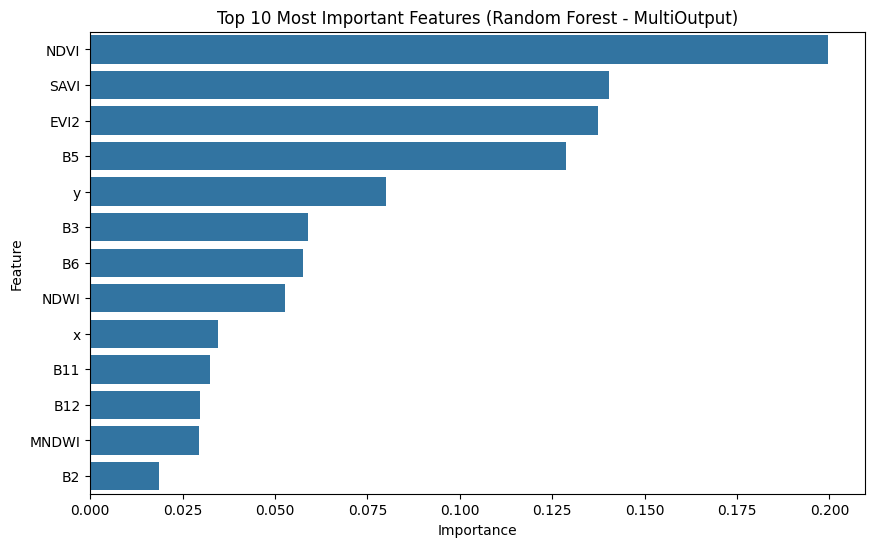

   Feature  Importance
8     NDVI    0.199694
10    SAVI    0.140249
9     EVI2    0.137293
4       B5    0.128866
7        y    0.079965
3       B3    0.058925
5       B6    0.057609
11    NDWI    0.052709
6        x    0.034544
0      B11    0.032496
1      B12    0.029652
12   MNDWI    0.029473
2       B2    0.018525


In [ ]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

print(feature_importance_df)

,True_Dominant_Class,Pred_Dominant_Class,Match
0,grassland,tree_cover,False
1,tree_cover,tree_cover,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


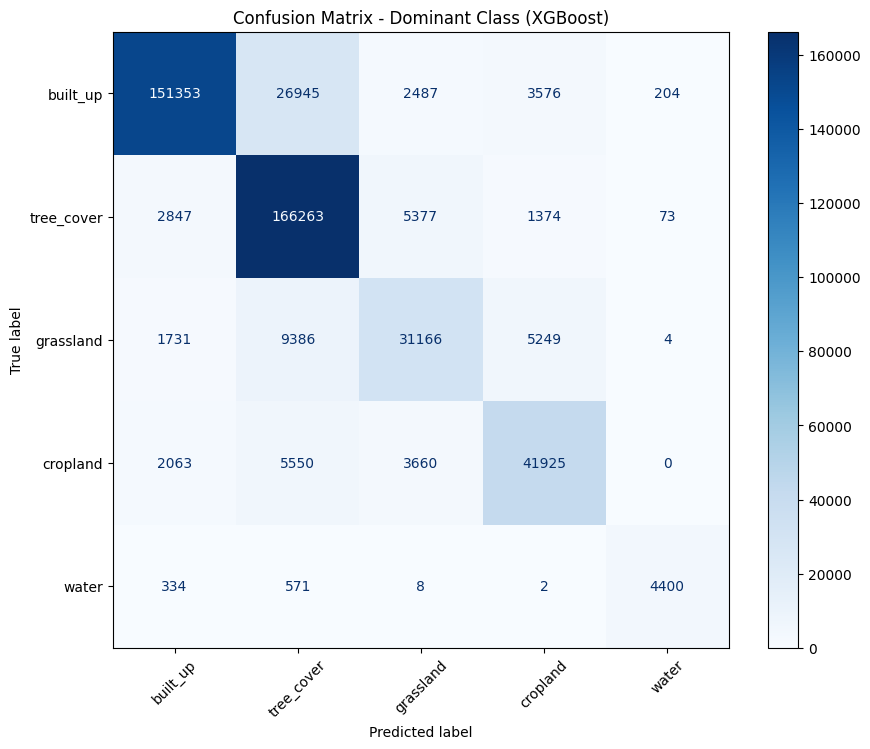

Overall Dominant Class Accuracy: 0.8469


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    'vegetation',
    'built_up',
    #'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation',
    'water'
]

best_model_name = "XGBoost"
y_pred_array = models[best_model_name].predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")